# Проект: Прогнозирование оттока клиентов телеком-компании

**Описание проекта**

Проект посвящён анализу данных о клиентах телекоммуникационной компании с целью выявления факторов, влияющих на уход клиентов (churn). Данные включают информацию о персональных характеристиках клиентов, типе их контрактов, платежах, используемых услугах и дополнительных сервисах (интернет, телефон, онлайн-защита, стриминговые сервисы и т.д.).


**Цель исследования**

Построить модель прогнозирования ухода клиентов телекоммуникационной компании и выявить ключевые факторы, влияющие на вероятность оттока, чтобы компания могла заранее определять клиентов с высоким риском ухода и принимать меры для их удержания, повышая лояльность и снижая финансовые потери.


**Ход исследования**

Для достижения поставленной цели будут выполнены следующие шаги:

- Ознакомление с данными каждого из датасетов;
- Предобработка данных;
- Исследовательский анализ данных (EDA);
- Подготовка данных к обучению;
- Обучение моделей градиентного бустинга (LightGBM  и CatBoost);
- Выбор лучшей модели;
- Анализ результатов.

Также в заключительной части проекта будут сформулированы итоговые выводы и рекомендации для заказчика.

## Настройка среды

In [1]:
# устанавливаем библиотеки
!pip install phik -q
!pip install shap -q

In [2]:
# обновляем библиотеки
!pip install -U scikit-learn
!pip install --upgrade catboost

     |████████████████████████████████| 13.5 MB 2.8 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 107.6 MB/s eta 0:00:01
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.24.1
    Uninstalling scikit-learn-0.24.1:
      Successfully uninstalled scikit-learn-0.24.1
     |████████████████████████████████| 99.2 MB 106 kB/s  eta 0:00:01
  Attempting uninstall: catboost
    Found existing installation: catboost 1.0.3
    Uninstalling catboost-1.0.3:
      Successfully uninstalled catboost-1.0.3


In [3]:
# импорт основных библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from phik import phik_matrix
import shap
import time

In [4]:
# импорт функций для МО
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay

# константы
RANDOM_STATE = 20226
TEST_SIZE = 0.25

## Ознакомление с данными

Оператор предоставляет два основных типа услуг: 
- **Стационарную телефонную связь**. Телефон можно подключить к нескольким линиям одновременно.
- **Интернет**. Подключение может быть двух типов: через телефонную линию (DSL, от англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (Fiber optic).

Также доступны такие услуги:
- Интернет-безопасность: антивирус (DeviceProtection) и блокировка небезопасных сайтов (OnlineSecurity);
- Выделенная линия технической поддержки (TechSupport);
- Облачное хранилище файлов для резервного копирования данных (OnlineBackup);
- Стриминговое телевидение (StreamingTV) и каталог фильмов (StreamingMovies).

Клиенты могут платить за услуги каждый месяц или заключить договор на 1–2 года. Возможно оплатить счёт разными способами, а также получить электронный чек.

Данные состоят из нескольких файлов, полученных из разных источников:
- **contract_new.csv** — информация о договоре;
- **personal_new.csv** — персональные данные клиента;
- **internet_new.csv** — информация об интернет-услугах;
- **phone_new.csv** — информация об услугах телефонии.

Во всех файлах столбец **customerID** содержит код клиента. Информация о договорах актуальна на 1 февраля 2020 года.

### Информация о договоре

- **customerID** — идентификатор абонента;
- **BeginDate** — дата начала действия договора;
- **EndDate** — дата окончания действия договора;
- **Type** — тип оплаты: раз в год-два или ежемесячно;
- **PaperlessBilling** — электронный расчётный лист;
- **PaymentMethod** — тип платежа;
- **MonthlyCharges** — расходы за месяц;
- **TotalCharges** — общие расходы абонента.

In [5]:
# сохраняем датасет в переменную
try:
    # пробуем загрузить локальный файл
    contract_data = pd.read_csv('contract_new.csv')
    print("Файл успешно загружен с локального пути.")
except FileNotFoundError:
    # если локальный файл не найден, пробуем общий путь
    try:
        contract_data = pd.read_csv('/datasets/contract_new.csv')
        print("Файл успешно загружен с пути '/datasets/contract_new.csv'.")
    except FileNotFoundError:
        print("Файл не найден ни по локальному, ни по общему пути. Проверьте расположение CSV.")

Файл успешно загружен с пути '/datasets/contract_new.csv'.


In [6]:
# первые 10 строк
contract_data.head(10)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5
5,9305-CDSKC,2019-03-01,No,Month-to-month,Yes,Electronic check,99.65,1150.96
6,1452-KIOVK,2018-04-01,No,Month-to-month,Yes,Credit card (automatic),89.10,2058.21
7,6713-OKOMC,2019-04-01,No,Month-to-month,No,Mailed check,29.75,300.48
8,7892-POOKP,2017-07-01,No,Month-to-month,Yes,Electronic check,104.80,3573.68
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,1628.35


In [7]:
# общая информация
contract_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [8]:
# размерность
print(f'Размерность: {contract_data.shape[0]} строк, {contract_data.shape[1]} столбцов')

Размерность: 7043 строк, 8 столбцов


In [9]:
# статистическое описание признаков
contract_data.describe().T

,count,mean,std,min,25%,50%,75%,max
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


### Персональные данные клиента

- **customerID** — идентификатор пользователя;
- **gender** — пол;
- **SeniorCitizen** — является ли абонент пенсионером;
- **Partner** — есть ли у абонента супруг или супруга;
- **Dependents** — есть ли у абонента дети.

In [10]:
# сохраняем датасет в переменную
try:
    # пробуем загрузить локальный файл
    personal_data = pd.read_csv('personal_new.csv')
    print("Файл успешно загружен с локального пути.")
except FileNotFoundError:
    # если локальный файл не найден, пробуем общий путь
    try:
        personal_data = pd.read_csv('/datasets/personal_new.csv')
        print("Файл успешно загружен с пути '/datasets/personal_new.csv'.")
    except FileNotFoundError:
        print("Файл не найден ни по локальному, ни по общему пути. Проверьте расположение CSV.")

Файл успешно загружен с пути '/datasets/personal_new.csv'.


In [11]:
# первые 10 строк
personal_data.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
5,9305-CDSKC,Female,0,No,No
6,1452-KIOVK,Male,0,No,Yes
7,6713-OKOMC,Female,0,No,No
8,7892-POOKP,Female,0,Yes,No
9,6388-TABGU,Male,0,No,Yes


In [12]:
# общая информация
personal_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [13]:
# размерность
print(f'Размерность: {personal_data.shape[0]} строк, {personal_data.shape[1]} столбцов')

Размерность: 7043 строк, 5 столбцов


In [14]:
# статистическое описание признаков
personal_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0


### Информация об интернет-услугах

- **customerID** — идентификатор пользователя;
- **InternetService** — тип подключения;
- **OnlineSecurity** — блокировка опасных сайтов;
- **OnlineBackup** — облачное хранилище файлов для резервного копирования данных;
- **DeviceProtection** — антивирус;
- **TechSupport** — выделенная линия технической поддержки;
- **StreamingTV** — стриминговое телевидение;
- **StreamingMovies** — каталог фильмов.

In [15]:
# сохраняем датасет в переменную
try:
    # пробуем загрузить локальный файл
    internet_data = pd.read_csv('internet_new.csv')
    print("Файл успешно загружен с локального пути.")
except FileNotFoundError:
    # если локальный файл не найден, пробуем общий путь
    try:
        internet_data = pd.read_csv('/datasets/internet_new.csv')
        print("Файл успешно загружен с пути '/datasets/internet_new.csv'.")
    except FileNotFoundError:
        print("Файл не найден ни по локальному, ни по общему пути. Проверьте расположение CSV.")

Файл успешно загружен с пути '/datasets/internet_new.csv'.


In [16]:
# первые 10 строк
internet_data.head(10)

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,Fiber optic,No,No,Yes,No,Yes,Yes
6,1452-KIOVK,Fiber optic,No,Yes,No,No,Yes,No
7,6713-OKOMC,DSL,Yes,No,No,No,No,No
8,7892-POOKP,Fiber optic,No,No,Yes,Yes,Yes,Yes
9,6388-TABGU,DSL,Yes,Yes,No,No,No,No


In [17]:
# общая информация
internet_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [18]:
# размерность
print(f'Размерность: {internet_data.shape[0]} строк, {internet_data.shape[1]} столбцов')

Размерность: 5517 строк, 8 столбцов


In [19]:
# статистическое описание признаков
internet_data.describe().T

,count,unique,top,freq
customerID,5517,5517,3179-GBRWV,1
InternetService,5517,2,Fiber optic,3096
OnlineSecurity,5517,2,No,3498
OnlineBackup,5517,2,No,3088
DeviceProtection,5517,2,No,3095
TechSupport,5517,2,No,3473
StreamingTV,5517,2,No,2810
StreamingMovies,5517,2,No,2785


### Информация об услугах телефонии

- **customerID** — идентификатор пользователя;
- **MultipleLines** — подключение телефона к нескольким линиям одновременно.

In [20]:
# сохраняем датасет в переменную
try:
    # пробуем загрузить локальный файл
    phone_data = pd.read_csv('phone_new.csv')
    print("Файл успешно загружен с локального пути.")
except FileNotFoundError:
    # если локальный файл не найден, пробуем общий путь
    try:
        phone_data = pd.read_csv('/datasets/phone_new.csv')
        print("Файл успешно загружен с пути '/datasets/phone_new.csv'.")
    except FileNotFoundError:
        print("Файл не найден ни по локальному, ни по общему пути. Проверьте расположение CSV.")

Файл успешно загружен с пути '/datasets/phone_new.csv'.


In [21]:
# первые 10 строк
phone_data.head(10)

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
5,7892-POOKP,Yes
6,6388-TABGU,No
7,9763-GRSKD,No
8,7469-LKBCI,No
9,8091-TTVAX,Yes


In [22]:
# общая информация
phone_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [23]:
# размерность
print(f'Размерность: {phone_data.shape[0]} строк, {phone_data.shape[1]} столбцов')

Размерность: 6361 строк, 2 столбцов


In [24]:
# статистическое описание признаков
phone_data.describe().T

,count,unique,top,freq
customerID,6361,6361,6248-TKCQV,1
MultipleLines,6361,2,No,3390


<div style="border: 2px solid black; padding: 10px;">
  <strong>На этапе предобработки требуется:</strong>
  <ul> 
    <li>Изменить названия столбцов;</li>
    <li>Проверить датафрейм на наличие дубликатов и устранить их;</li> 
    <li>Проверить датафрейм на наличие пропусков и по возможности устранить их;</li>  
    <li>Проверить тип данных столбцов;</li>
    <li>Проверить данные на наличие ошибок и устранить их.</li>  
      
  После предобработки данные будут пригодны для объединения и дальнейшего анализа.  
  </ul>
</div>

## Предобработка данных

### Изменение названий столбцов

#### Информация о договоре

In [25]:
# для удобства переименуем столбцы
contract_data.rename(columns={
    'customerID': 'customer_id',
    'BeginDate': 'begin_date',
    'EndDate': 'end_date',
    'Type': 'type',
    'PaperlessBilling': 'paperless_billing',
    'PaymentMethod': 'payment_method',
    'MonthlyCharges': 'monthly_charges',
    'TotalCharges': 'total_charges'
}, inplace=True)

# ознакомление с датасетом после изменений
contract_data.head(1)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04


#### Персональные данные клиента

In [26]:
# для удобства переименуем столбцы
personal_data.rename(columns={
    'customerID': 'customer_id',
    'gender': 'gender',
    'SeniorCitizen': 'senior_citizen',
    'Partner': 'partner',
    'Dependents': 'dependents'
}, inplace=True)

# ознакомление с датасетом после изменений
personal_data.head(1)

,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,0,Yes,No


#### Информация об интернет-услугах

In [27]:
# для удобства переименуем столбцы
internet_data.rename(columns={
    'customerID': 'customer_id',
    'InternetService': 'internet_service',
    'OnlineSecurity': 'online_security',
    'OnlineBackup': 'online_backup',
    'DeviceProtection': 'device_protection',
    'TechSupport': 'tech_support',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_movies'
}, inplace=True)

# ознакомление с датасетом после изменений
internet_data.head(1)

,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No


#### Информация об услугах телефонии

In [28]:
# для удобства переименуем столбцы
phone_data.rename(columns={
    'customerID': 'customer_id',
    'MultipleLines': 'multiple_lines'
}, inplace=True)

# ознакомление с датасетом после изменений
phone_data.head(1)

,customer_id,multiple_lines
0,5575-GNVDE,No


### Обработка дубликатов

Сначала проверим датасеты на наличие неявных дубликатов в строковых столбцах, после чего обработаем явные дубликаты.

In [29]:
# категориальные столбцы
cat_columns = ['begin_date', 'end_date', 'type', 'paperless_billing', 'payment_method', 'total_charges', 'gender',
               'partner', 'dependents', 'internet_service', 'online_secutity', 'online_backup',
               'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']

# словарь датафреймов
dataframes = {
    'contract_data': contract_data,
    'personal_data': personal_data,
    'internet_data': internet_data,
    'phone_data': phone_data
    
}

# проверим уникальные значения некоторых столбцов
for name, df in dataframes.items():
    print(f'----- Уникальные значения в столбцах {name}: -----')
    for category in cat_columns:
        if category in df.columns:
            print()
            print(f'{category}: {df[category].dropna().sort_values().unique()}')
    print()

----- Уникальные значения в столбцах contract_data: -----

begin_date: ['2013-10-01' '2013-11-01' '2013-12-01' '2014-01-01' '2014-02-01'
 '2014-03-01' '2014-04-01' '2014-05-01' '2014-06-01' '2014-07-01'
 '2014-08-01' '2014-09-01' '2014-10-01' '2014-11-01' '2014-12-01'
 '2015-01-01' '2015-02-01' '2015-03-01' '2015-04-01' '2015-05-01'
 '2015-06-01' '2015-07-01' '2015-08-01' '2015-09-01' '2015-10-01'
 '2015-11-01' '2015-12-01' '2016-01-01' '2016-02-01' '2016-03-01'
 '2016-04-01' '2016-05-01' '2016-06-01' '2016-07-01' '2016-08-01'
 '2016-09-01' '2016-10-01' '2016-11-01' '2016-12-01' '2017-01-01'
 '2017-02-01' '2017-03-01' '2017-04-01' '2017-05-01' '2017-06-01'
 '2017-07-01' '2017-08-01' '2017-09-01' '2017-10-01' '2017-11-01'
 '2017-12-01' '2018-01-01' '2018-02-01' '2018-03-01' '2018-04-01'
 '2018-05-01' '2018-06-01' '2018-07-01' '2018-08-01' '2018-09-01'
 '2018-10-01' '2018-11-01' '2018-12-01' '2019-01-01' '2019-02-01'
 '2019-03-01' '2019-04-01' '2019-05-01' '2019-06-01' '2019-07-01'
 '201

In [30]:
# считаем пустые строки по каждому столбцу
empty_strings = (contract_data == ' ').sum()

# оставляем только те столбцы, где есть пустые строки
empty_strings = empty_strings[empty_strings > 0]

# вывод
for col, count in empty_strings.items():
    print(f"Количество пустых строк в столбце {col}: {count}")

Количество пустых строк в столбце total_charges: 11


В столбце **total_charges** обнаружены пустые строки, которые скорее всего появились из-за клиентов с очень коротким сроком обслуживания. Заменим эти значения на 0 и приведем к вещественному типу:

In [31]:
# заменяем пустые значения на 0 и сразу приводим к float
contract_data['total_charges'] = contract_data['total_charges'].replace(' ', 0).astype(float)

print('Количество пропусков в total_charges:', contract_data['total_charges'].isna().sum())

Количество пропусков в total_charges: 0


Неявные дубли в строковых столбцах отсутствуют. Теперь проверим датасеты на наличие явных дубликатов:

In [32]:
# проверяем данные на наличие явных дубликатов
print(f"Количество явных дубликатов в contract_data: {contract_data.duplicated().sum()}")
print(f"Количество явных дубликатов в personal_data: {personal_data.duplicated().sum()}")
print(f"Количество явных дубликатов в internet_data: {internet_data.duplicated().sum()}")
print(f"Количество явных дубликатов в phone_data: {phone_data.duplicated().sum()}")

Количество явных дубликатов в contract_data: 0
Количество явных дубликатов в personal_data: 0
Количество явных дубликатов в internet_data: 0
Количество явных дубликатов в phone_data: 0


### Обработка пропусков

In [33]:
# проверяем количество пропусков в данных
print('contract_data')
contract_data.isna().sum()

contract_data


customer_id          0
begin_date           0
end_date             0
type                 0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
dtype: int64

In [34]:
# проверяем количество пропусков в данных
print('personal_data')
personal_data.isna().sum()

personal_data


customer_id       0
gender            0
senior_citizen    0
partner           0
dependents        0
dtype: int64

In [35]:
# проверяем количество пропусков в данных
print('internet_data')
internet_data.isna().sum()

internet_data


customer_id          0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
dtype: int64

In [36]:
# проверяем количество пропусков в данных
print('phone_data')
phone_data.isna().sum()

phone_data


customer_id       0
multiple_lines    0
dtype: int64

Пропуски отсутствуют.

### Изменение типов данных

In [37]:
# проверяем типы данных contract_data
contract_data.dtypes

customer_id           object
begin_date            object
end_date              object
type                  object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
dtype: object

In [38]:
# проверяем типы данных personal_data
personal_data.dtypes

customer_id       object
gender            object
senior_citizen     int64
partner           object
dependents        object
dtype: object

 Переведем признак **senior_citizen** в категориальный:

In [39]:
# преобразуем senior_citizen в категориальный Yes/No
personal_data['senior_citizen'] = personal_data['senior_citizen'].map({1: 'Yes', 0: 'No'})

# проверяем изменения
personal_data.dtypes

customer_id       object
gender            object
senior_citizen    object
partner           object
dependents        object
dtype: object

In [40]:
# проверяем типы данных internet_data
internet_data.dtypes

customer_id          object
internet_service     object
online_security      object
online_backup        object
device_protection    object
tech_support         object
streaming_tv         object
streaming_movies     object
dtype: object

In [41]:
# проверяем типы данных phone_data
phone_data.dtypes

customer_id       object
multiple_lines    object
dtype: object

### Feature Engineering: создание и отбор признаков

Признаки **begin_date** и **end_date** (contract_data) содержат даты начала и окончания договора. Значение «No» в end_date означает, что договор был активен на момент формирования выборки (01.02.2020).

Поскольку данные признаки привязаны к конкретному моменту времени, их прямое использование может привести к некорректным предсказаниям при применении модели на новых данных. Поэтому на их основе следует создать новые признаки, после чего исходные признаки удалить.

Следует создать целевой признак **churn**:

- 1 — договор расторгнут (если в end_date указана дата),
- 0 — договор активен (если end_date = «No»).

Также следует создать признак **duration_contract** — длительность договора в днях. Для расчёта продолжительности обслуживания значения «No» в end_date будут заменены на дату 01.02.2020, после чего будет рассчитано количество дней.

In [42]:
# создаём целевой признак churn
# если end_date = 'No', то договор активен (churn = 0)
# если иначе, то договор расторгнут (churn = 1)
contract_data['churn'] = np.where(contract_data['end_date'] == 'No', 0, 1)

# заменяем 'No' на актуальную дату для расчёта duration
contract_data['end_date'] = contract_data['end_date'].replace('No', '2020-02-01')

# переводим даты в datetime
contract_data['begin_date'] = pd.to_datetime(contract_data['begin_date'])
contract_data['end_date'] = pd.to_datetime(contract_data['end_date'])

# создаём длительность контракта в днях
contract_data['duration_contract'] = (contract_data['end_date'] - contract_data['begin_date']).dt.days

# удаляем исходные признаки
contract_data = contract_data.drop(columns=['begin_date', 'end_date'])

# проверка
contract_data.head()

,customer_id,type,paperless_billing,payment_method,monthly_charges,total_charges,churn,duration_contract
0,7590-VHVEG,Month-to-month,Yes,Electronic check,29.85,31.04,0,31
1,5575-GNVDE,One year,No,Mailed check,56.95,2071.84,0,1036
2,3668-QPYBK,Month-to-month,Yes,Mailed check,53.85,226.17,0,123
3,7795-CFOCW,One year,No,Bank transfer (automatic),42.30,1960.60,0,1371
4,9237-HQITU,Month-to-month,Yes,Electronic check,70.70,353.50,0,153


<div style="border: 2px solid black; padding: 10px;">
  <strong>Итоги предобработки данных:</strong>
  <ul>
    <li>Изменены названия столбцов;</li>  
    <li>Данные проверены на наличие дубликатов и пропусков;</li>  
    <li>Типы данных проверены и изменены там, где это необходимо;</li>  
    <li>Созданы новые признаки (в том числе целевой), удалены неинформативные признаки.</li>  

  Теперь датасеты готовы к объединению.  
  </ul>
</div>

## Объединение данных

Проверяем размерность датасетов перед объединением:

In [43]:
# проверка размерности
print('Размерность датафрейма contract_data:', contract_data.shape)
print('Размерность датафрейма personal_data:', personal_data.shape)
print('Размерность датафрейма internet_data:', internet_data.shape)
print('Размерность датафрейма phone_data:   ', phone_data.shape)

Размерность датафрейма contract_data: (7043, 8)
Размерность датафрейма personal_data: (7043, 5)
Размерность датафрейма internet_data: (5517, 8)
Размерность датафрейма phone_data:    (6361, 2)


Логика объединения:
- Начинаем с **contract_data** — это главный датасет с целевым признаком **churn**;
- Добавляем **personal_data** — все клиенты есть, merge будет на все строки;
- Добавляем **internet_data и phone_data** — здесь будет много пропусков для тех, кто не подключал услугу, их можно заполнить как 'No' или 0, в зависимости от признака.

In [44]:
# объединяем contract и personal (по всем клиентам)
full_data = contract_data.merge(personal_data, on='customer_id', how='left')

# объединяем internet_data (не у всех клиентов есть интернет)
full_data = full_data.merge(internet_data, on='customer_id', how='left')

# объединяем phone_data (не у всех клиентов есть телефония)
full_data = full_data.merge(phone_data, on='customer_id', how='left')

# проверяем размерность итогового датасета
print("Размерность объединённого датафрейма:", full_data.shape)

Размерность объединённого датафрейма: (7043, 20)


In [45]:
# проверяем объединенный датафрейм
full_data.head(3)

,customer_id,type,paperless_billing,payment_method,monthly_charges,total_charges,churn,duration_contract,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,Month-to-month,Yes,Electronic check,29.85,31.04,0,31,Female,No,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,One year,No,Mailed check,56.95,2071.84,0,1036,Male,No,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,Month-to-month,Yes,Mailed check,53.85,226.17,0,123,Male,No,No,No,DSL,Yes,Yes,No,No,No,No,No


In [46]:
# проверяем наличие пропусков
full_data.isna().sum()

customer_id             0
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
churn                   0
duration_contract       0
gender                  0
senior_citizen          0
partner                 0
dependents              0
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
multiple_lines        682
dtype: int64

Ожидаемо есть пропуски, но их лучше не заполнять 'Yes'/'No', так как модель может перепутать:
- 'No' по конкретной услуге - клиент подключен, но не пользуется (например, нет OnlineSecurity),
- 'No' по пропуску - клиент вообще не подключен к интернету.

Чтобы разделить эти случаи, лучше в NaN от интернет/телефонии вставить отдельную категорию, например 'None'.

In [47]:
# список признаков интернет-услуг
internet_cols = ['internet_service','online_security','online_backup',
                 'device_protection','tech_support','streaming_tv','streaming_movies']

# список признаков телефонии
phone_cols = ['multiple_lines']

# заполняем пропуски отдельной категорией
full_data[internet_cols] = full_data[internet_cols].fillna('None')
full_data[phone_cols] = full_data[phone_cols].fillna('None')

# проверяем наличие пропусков
full_data.isna().sum()

customer_id          0
type                 0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
duration_contract    0
gender               0
senior_citizen       0
partner              0
dependents           0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
multiple_lines       0
dtype: int64

<div style="border: 2px solid black; padding: 10px;">
  <strong>Итоги объединения данных:</strong>
  <ul>
    <li>Данные четырех датасетов успешно объеденены;</li>  
    <li>Новый датафрейм проверен на наличие пропусков;</li>  
    <li>Пропуски заполнены в соответствии с их природой.</li> 

  Теперь данные готовы к исследовательскому анализу.  
  </ul>
</div>

## Исследовательский анализ данных

### Распределения признаков

На данном этапе мы проведем статистический анализ всех признаков, а также построим графики для каждого из них с учетом того, что количественным и категориальным данным подходят разные способы визуализации. Это поможет заметить выбросы, необычное распределение количественных признаков и другие особенности с целью улучшить данные и подготовить их к моделированию.

Исследуем распределение целевого признака:

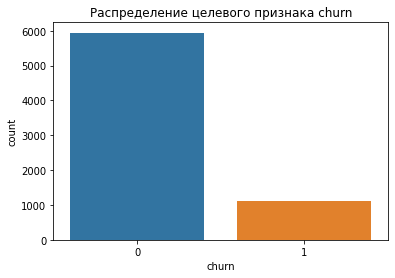

In [48]:
# проверяем распределение целевого признака churn
sns.countplot(x='churn', data=full_data)
plt.title('Распределение целевого признака churn')
plt.show()

<div style="border: 2px solid black; padding: 10px;">
  <strong>Наблюдения по распределению целевого признака churn:</strong>
  <ul> 
    <li>Наблюдается выраженный дисбаланс классов, но это типично для задач прогнозирования оттока.</li>
    <li>Дисбаланс указывает на то, что отток является относительно редким событием, что характерно для телеком-сферы.</li>  
    <li>В качестве основной метрики необходимо выбрать ROC-AUC, так как она устойчива к дисбалансу классов и позволяет корректно оценить способность модели различать клиентов с высоким риском оттока.</li> 
    <li>Модели бустинга отлично справляются с дисбалансом классов, поэтому есть смысл использовать их (например, LightGBM и CatBoost).</li> 
  </ul>
</div>

Исследуем количественные признаки:

In [49]:
# количественные признаки
num_cols = full_data.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols.remove('churn')  # убираем целевой

# статистическое описание количественных признаков
full_data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
monthly_charges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
total_charges,7043.0,2115.312885,2112.742814,0.00,436.75,1343.35,3236.69,9221.38
duration_contract,7043.0,898.555729,683.130510,0.00,276.00,761.00,1461.00,2314.00


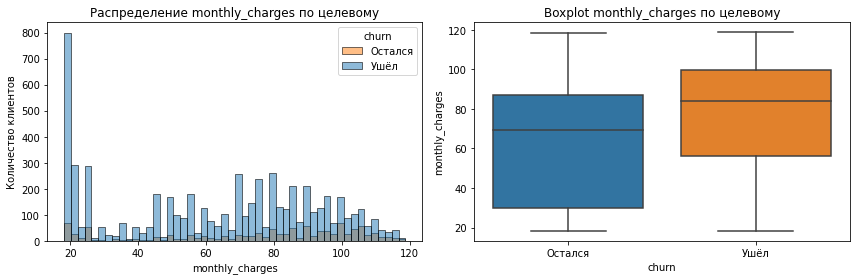

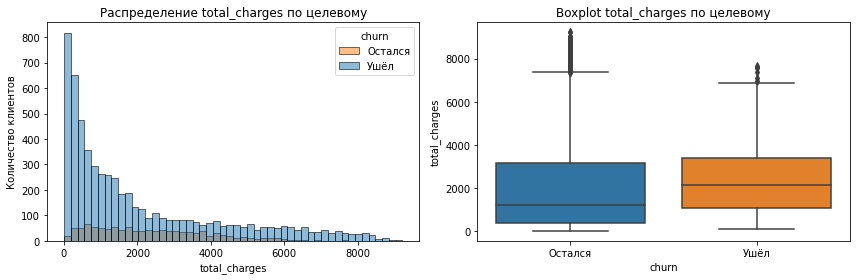

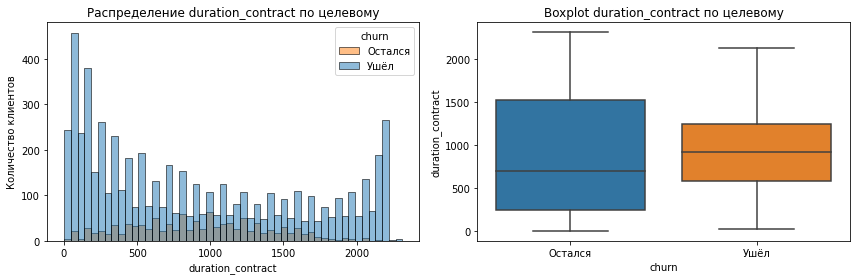

In [50]:
# графики для количественных признаков
for col in num_cols:
    plt.figure(figsize=(12, 4))

    # гистограмма с разделением по целевому
    plt.subplot(1, 2, 1)
    sns.histplot(
        data=full_data, 
        x=col, 
        hue='churn', 
        kde=False,
        bins=50, 
        multiple='layer'
    )
    plt.title(f'Распределение {col} по целевому')
    plt.xlabel(col)
    plt.ylabel('Количество клиентов')
    plt.legend(title='сhurn', labels=['Остался', 'Ушёл'])

    # боксплот с разделением по целевому
    plt.subplot(1, 2, 2)
    sns.boxplot(
        data=full_data, 
        x='churn', 
        y=col
    )
    plt.title(f'Boxplot {col} по целевому')
    plt.xlabel('churn')
    plt.ylabel(col)
    plt.xticks([0, 1], ['Остался', 'Ушёл'])  # расшифровка по оси X

    plt.tight_layout()
    plt.show()

<div style="border: 2px solid black; padding: 10px;">
  <strong>Наблюдения по распределению количественных признаков:</strong>
  <ul> 
    <li><strong>monthly_charges:</strong> Распределение мультимодальное (имеет несколько пиков). У лояльных клиентов доминирует огромный пик в районе 20, тогда как у группы оттока — плоское распределение с широким плато между 70 и 110. Выбросы отсутствуют в обеих группах. Значения лежат в естественном диапазоне тарифов.</li>
    <li><strong>total_charges:</strong> Распределение сильно скошено вправо для обеих групп. Большинство данных сосредоточено у нуля, что типично для финансовых метрик. Наблюдается множество выбросов у лояльных клиентов (значения выше 7500). Это «старые» клиенты с высоким чеком. У группы оттока выбросов значительно меньше, так как они реже успевают накопить такие суммы.</li>
    <li><strong>duration_contract:</strong> У лояльных клиентов распределение ближе к равномерному, но со всплесками в начале и в самом конце. Выбросов нет у обеих групп.</li> 
  </ul>
</div>

Исследуем категориальные признаки:

In [51]:
# категориальные признаки
cat_cols = full_data.select_dtypes(include=['object','category']).columns.tolist()
cat_cols.remove('customer_id')  # убираем id

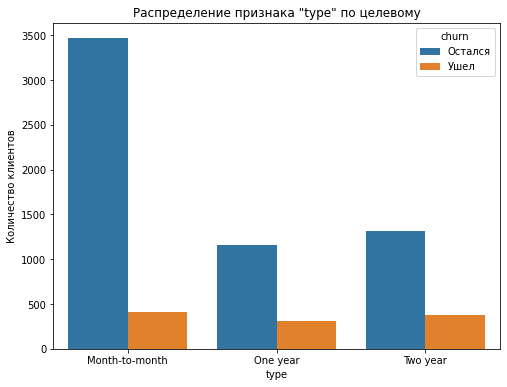

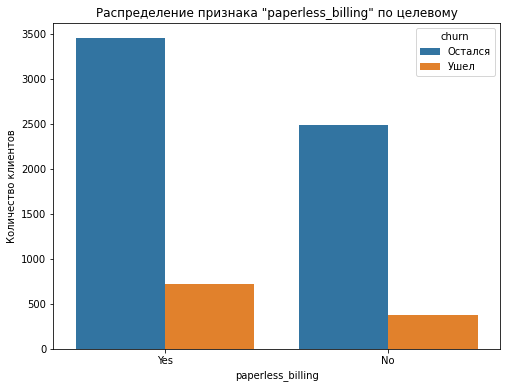

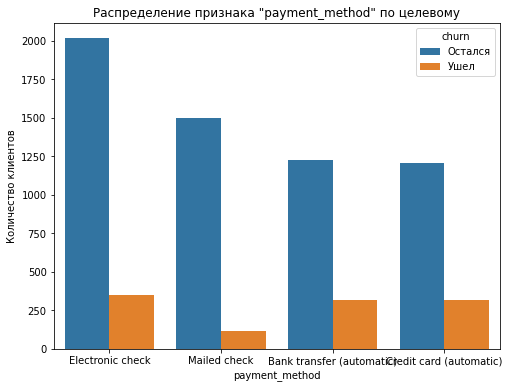

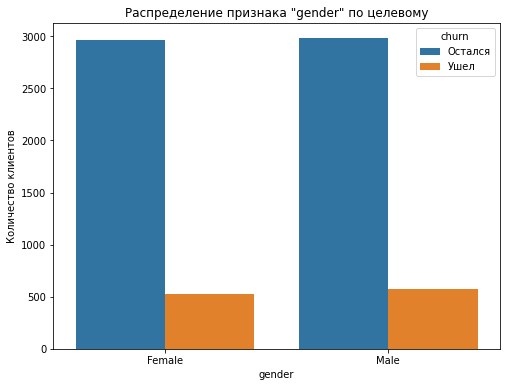

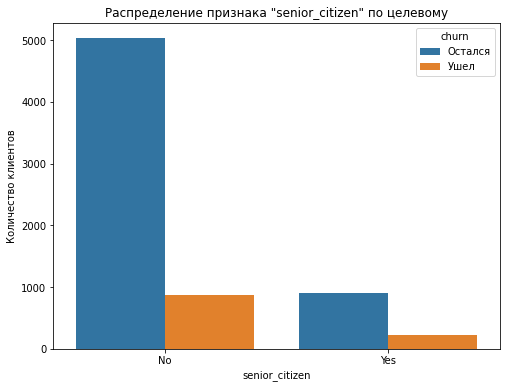

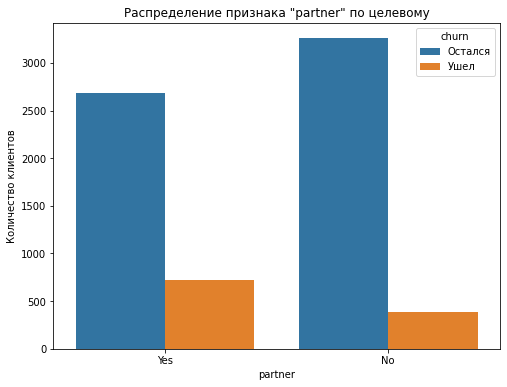

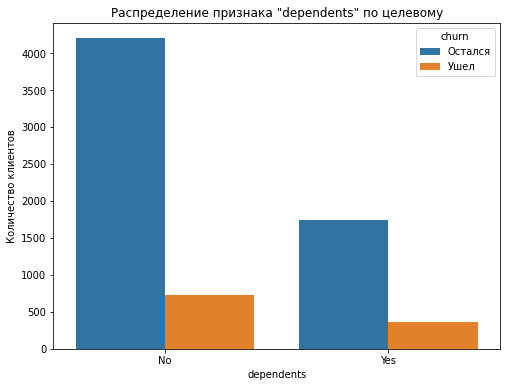

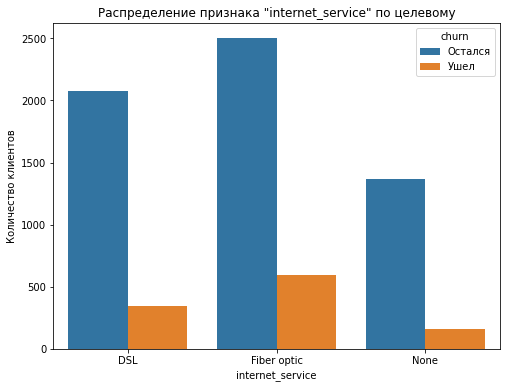

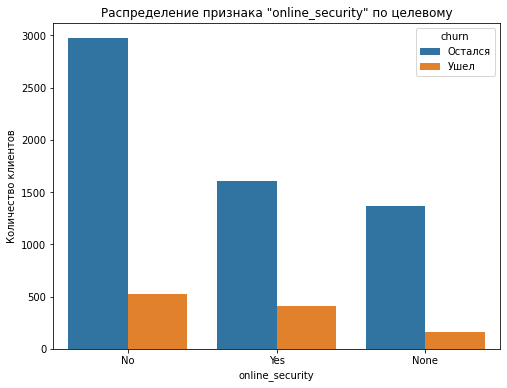

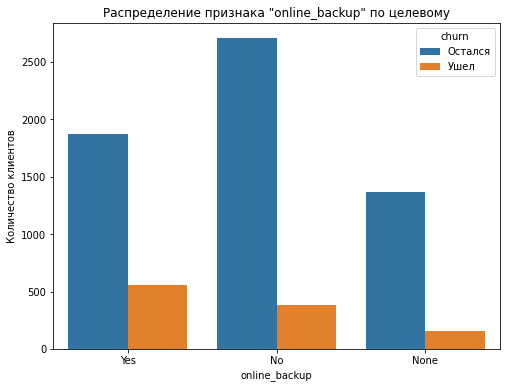

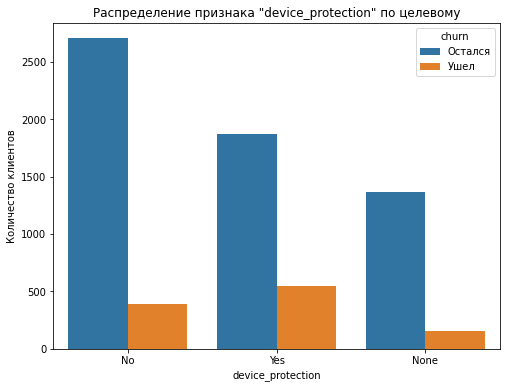

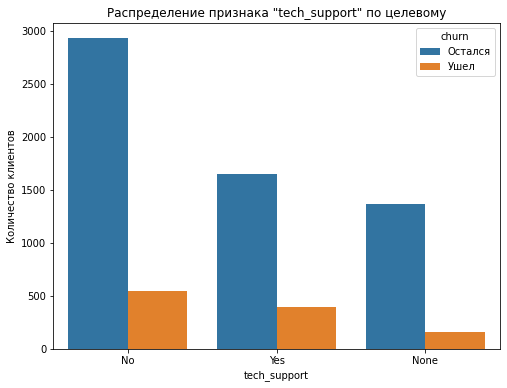

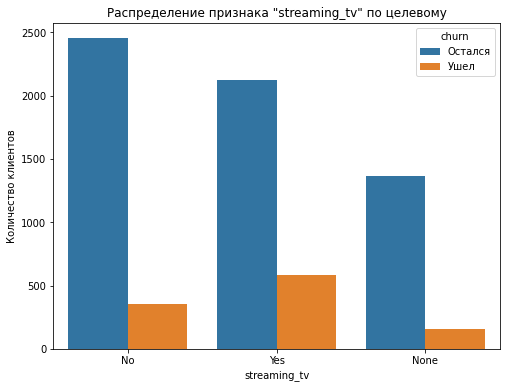

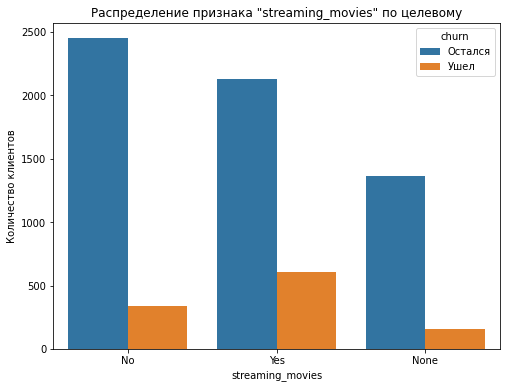

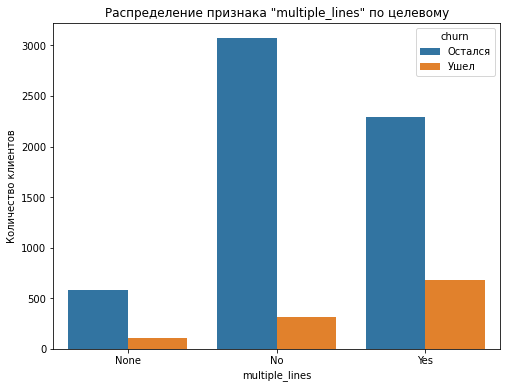

In [52]:
# выводим countplot для каждого столбца
for col in cat_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=col, data=full_data, hue='churn')
    plt.title(f'Распределение признака "{col}" по целевому')
    plt.xlabel(col)
    plt.ylabel('Количество клиентов')
    plt.legend(title='churn', labels=['Остался', 'Ушел'])
    plt.show() 

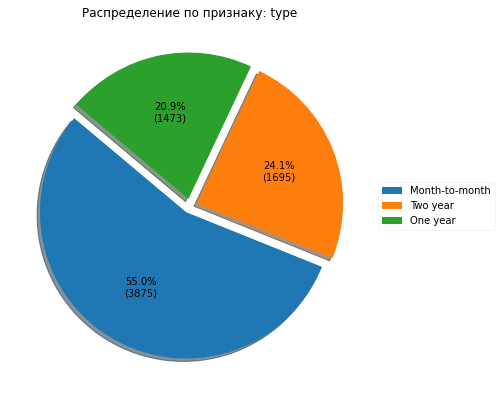

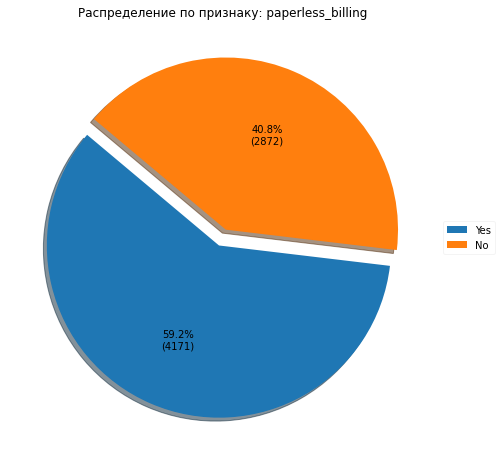

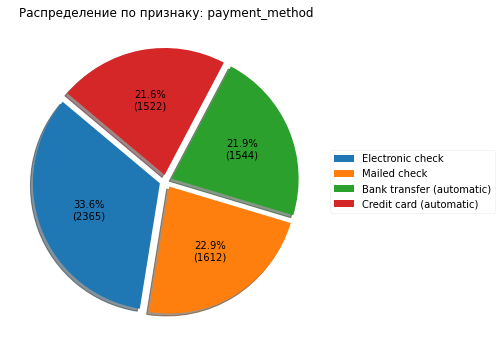

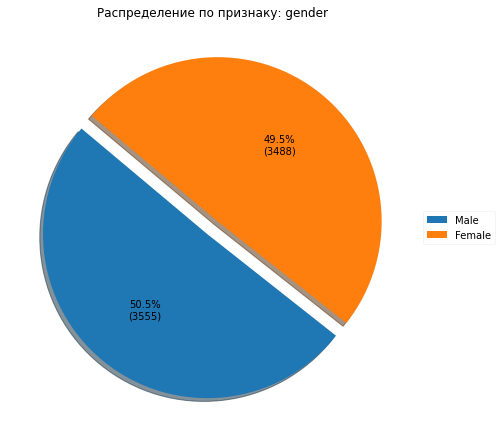

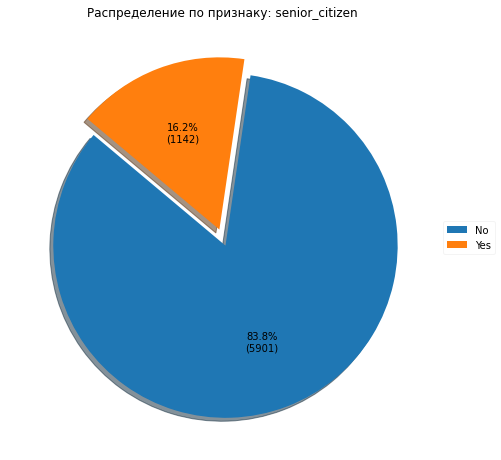

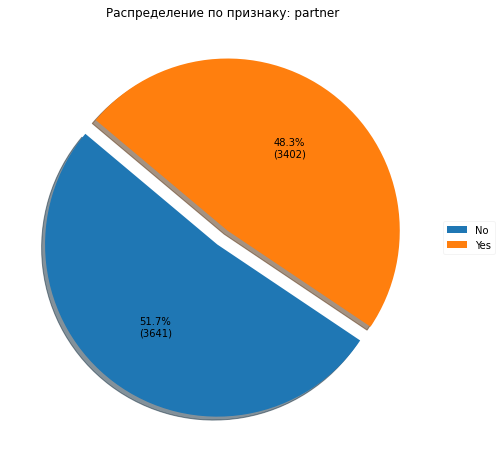

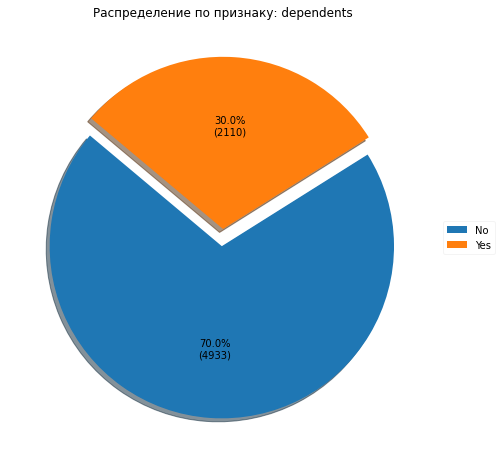

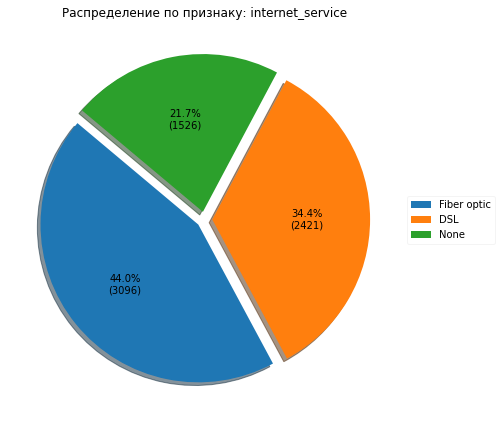

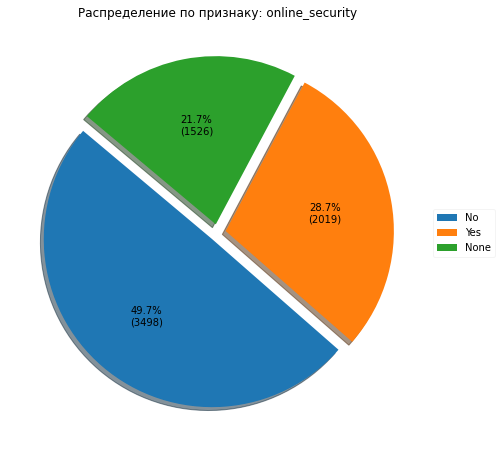

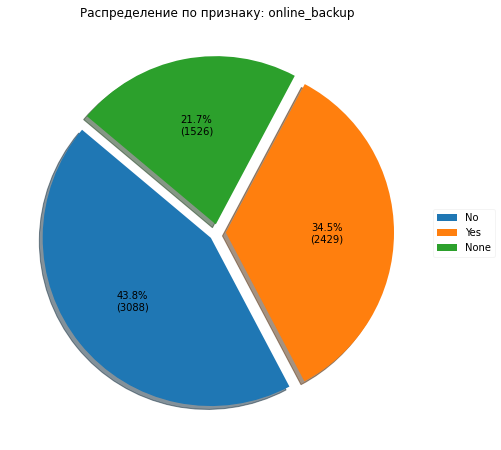

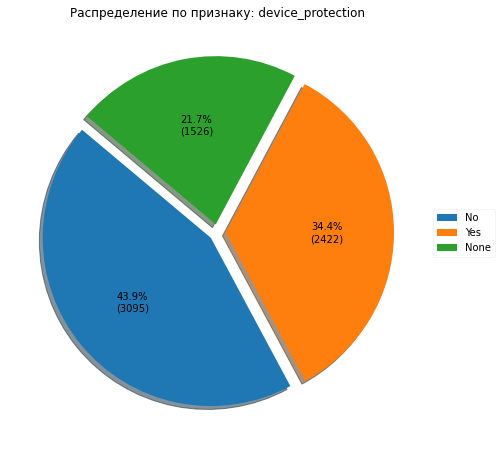

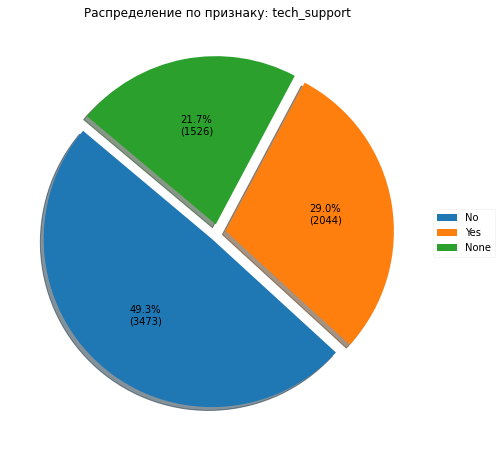

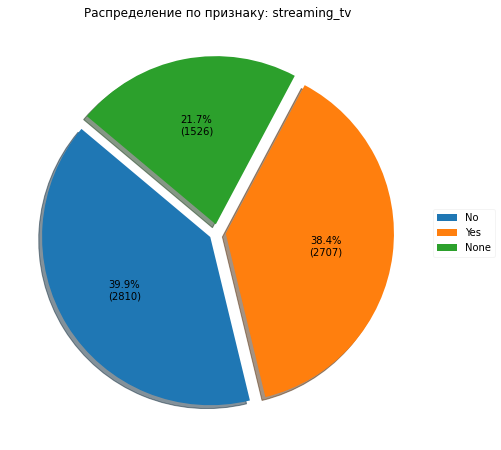

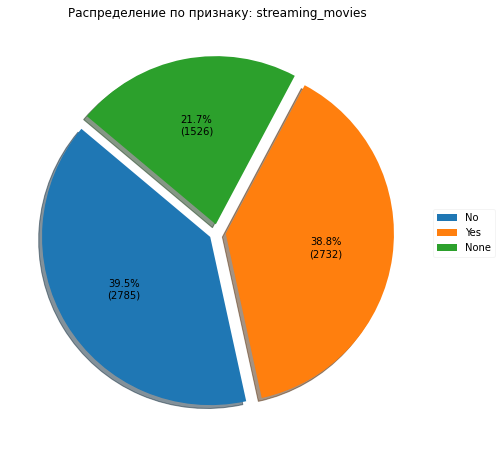

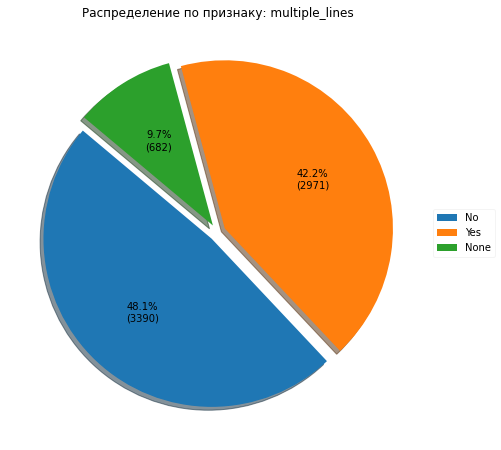

In [53]:
# строим круговые диаграммы для категориальных признаков
for col in cat_cols:
    counts = full_data[col].value_counts(dropna=False)
    labels = counts.index
    sizes = counts.values
    explode = [0.05] * len(labels) # чуть сдвигаем каждый сектор

    def make_autopct(values): # функция для корректного подсчета абсолютных значений
        def my_autopct(pct):
            total = sum(values)
            absolute = int(round(pct * total / 100.0))
            return f"{pct:.1f}%\n({absolute})"
        return my_autopct

    plt.figure(figsize=(7, 7))
    plt.pie(
        sizes,
        labels=None,
        autopct=make_autopct(sizes),
        startangle=140,
        explode=explode,
        shadow=True
    )
    plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, framealpha=0.2)
    plt.title(f'Распределение по признаку: {col}')
    plt.tight_layout()
    plt.show()

<div style="border: 2px solid black; padding: 10px;">
  <strong>Наблюдения по распределению категориальных признаков:</strong>
  <ul> 
    <li>Анализ категориальных признаков показал, что распределения значений являются логичными и отражают реальные особенности клиентской базы. Наиболее распространённым типом договора является помесячный контракт, что потенциально может быть связано с более высоким риском оттока.</li>
    <li>Социально-демографические признаки в целом сбалансированы, за исключением признака senior_citizen, где доля пенсионеров составляет около 16%.</li>
    <li>Признаки, характеризующие интернет-услуги, содержат отдельную категорию None, отражающую отсутствие подключения, что позволяет корректно учитывать различия между отсутствием услуги и отсутствием самого сервиса.</li> 
    <li>В целом категориальные признаки признаны информативными и пригодными для обучения моделей без дополнительного объединения категорий.</li> 
  </ul>
</div>

### Корреляционный анализ

На данном этапе мы изучим взаимосвязь между признаками: рассчитаем коэффициенты корреляции между ними и проанализируем корреляции.

Необходимо использовать подходы, которые устойчивы к выбросам и ненормальному распределению. Для этого построим матрицу корреляции по коэффициенту Phi (Phik), которая используется для категориальных признаков или пар числовых-категориальных признаков:

In [54]:
# отбираем количественные признаки, чтобы передать их как параметр при построении матрицы
# для корректного разделения признаков
num_cols = ['monthly_charges', 'total_charges', 'duration_contract']

# вычисляем phik корреляции и сразу исключаем из анализа признак customer_id
phik_corr = full_data.drop(columns=['customer_id']).phik_matrix(interval_cols=num_cols)

phik_corr

,type,paperless_billing,payment_method,monthly_charges,total_charges,churn,duration_contract,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
type,1.000000,0.106860,0.277462,0.388266,0.470860,0.094015,0.634155,0.000000,0.086231,0.179736,0.147680,0.505187,0.636884,0.581660,0.631531,0.671629,0.549564,0.553556,0.244410
paperless_billing,0.106860,1.000000,0.370495,0.467783,0.201703,0.083398,0.026799,0.000000,0.242133,0.013218,0.172593,0.231438,0.208320,0.195321,0.195687,0.200621,0.204717,0.202241,0.099953
payment_method,0.277462,0.370495,1.000000,0.399536,0.335666,0.214832,0.350964,0.000000,0.292725,0.243008,0.224903,0.323886,0.315799,0.293413,0.297923,0.317713,0.284531,0.285525,0.174849
monthly_charges,0.388266,0.467783,0.399536,1.000000,0.711035,0.225925,0.387579,0.009025,0.304691,0.203237,0.184213,0.918980,0.812633,0.818858,0.827318,0.816603,0.864642,0.863641,0.710101
total_charges,0.470860,0.201703,0.335666,0.711035,1.000000,0.302890,0.848337,0.000000,0.135650,0.381958,0.084247,0.490081,0.516538,0.550544,0.558393,0.527838,0.555322,0.554030,0.467787
churn,0.094015,0.083398,0.214832,0.225925,0.302890,1.000000,0.374569,0.008581,0.086159,0.226688,0.046871,0.056621,0.058659,0.089704,0.085608,0.051537,0.078545,0.086577,0.105101
duration_contract,0.634155,0.026799,0.350964,0.387579,0.848337,0.374569,1.000000,0.000000,0.063315,0.453688,0.198729,0.060845,0.346398,0.366170,0.374702,0.353438,0.306675,0.307297,0.347289
gender,0.000000,0.000000,0.000000,0.009025,0.000000,0.008581,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.001460,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
senior_citizen,0.086231,0.242133,0.292725,0.304691,0.135650,0.086159,0.063315,0.000000,1.000000,0.016992,0.324576,0.160702,0.127319,0.109995,0.110177,0.135283,0.111714,0.113778,0.087925
partner,0.179736,0.013218,0.243008,0.203237,0.381958,0.226688,0.453688,0.000000,0.016992,1.000000,0.652122,0.000000,0.091202,0.092012,0.100092,0.076326,0.082251,0.077506,0.086249


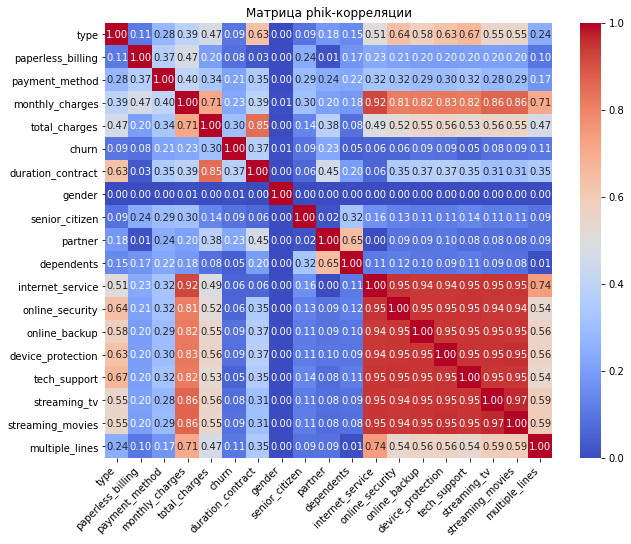

In [55]:
# визуализируем
plt.figure(figsize=(10, 8))
sns.heatmap(phik_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Матрица phik-корреляции")
plt.xticks(rotation=45, ha='right')
plt.show()

<div style="border: 2px solid black; padding: 10px;">
  <strong>Выводы по корреляции с целевым признаком churn:</strong>
  <ul>
    <li><strong>duration_contract (0.37):</strong> наиболее заметная корреляция;</li>
    <li><strong>total_charges (0.30):</strong> общая сумма расходов может быть индикатором ухода;</li>  
    <li><strong>monthly_charges, partner, payment_method:</strong> менее явные корреляции, но статистически значимые.</li>  
  </ul>
</div>

<div style="border: 2px solid black; padding: 10px;">
  <strong>Практическая интерпретация:</strong>
  <ul>
    <li>Признаки duration_contract, total_charges, monthly_charges — ключевые для предсказания оттока.</li>
    <li>Услуги (online_security, streaming_tv и т.д.) лучше кодировать как бинарные признаки (Yes/No) и оставить, т.к. модели могут обнаружить сложные взаимодействия.</li>  
    <li>В данных наблюдается мультиколлинеарность среди признаков интернет-услуг (0.94–0.97), что указывает на их сильную зависимость, но модели бустинга с этим справятся, поэтому признаки можно оставить.</li>
    <li>Признак gender можно исколючить из модели, так как он имеет низкую предсказательную ценность (нулевая корреляция).</li>    
  </ul>
</div>

## Моделирование

### Подготовка данных

На этапе подготовки данных необходимо:
- отобрать признаки, не содержащие утечек информации и имеющие потенциальную предсказательную силу (в нашем случае исключаем из набора признаки customer_id и gender);
- разделить данные на обучающую и тестовую выборки в соотношении 3:1 с использованием стратификации по целевому признаку;
- отедельно выделить категориальные и числовые признаки для дальнейшего использования в моделях.

In [56]:
# итоговый набор признаков (оставляем все кроме customer_id и gender)
features = [
    'type',
    'paperless_billing',
    'payment_method',
    'monthly_charges',
    'total_charges',
    'duration_contract',
    'senior_citizen',
    'partner',
    'dependents',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'multiple_lines'
]

# целевой признак
target = 'churn'

# делим признаки
X = full_data[features]
y = full_data[target]

In [57]:
# формируем выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# проверяем признаки
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Категориальные:", cat_cols)
print("Числовые:", num_cols)

Категориальные: ['type', 'paperless_billing', 'payment_method', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']
Числовые: ['monthly_charges', 'total_charges', 'duration_contract']


In [58]:
# проверяем размерность выборок
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5282, 17)
X_test : (1761, 17)
y_train: (5282,)
y_test : (1761,)


### Обучение моделей

На этапе обучения моделей были выбраны алгоритмы градиентного бустинга (LightGBM и CatBoost), так как лучше всего подходят для имеющихся данных и текущей задачи.
Для каждой модели проведем кросс-валидацию и подбор гиперпараметров с использованием ROC-AUC в качестве основной метрики.
По результатам сравнения выберем модель с наилучшим качеством, которая затем будет проверена на тестовой выборке.

#### LightGBM

In [59]:
# кодирование категориальных признаков для LightGBM
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_lgb[col] = le.fit_transform(X_train_lgb[col])
    X_test_lgb[col] = le.transform(X_test_lgb[col])
    le_dict[col] = le

# настройка модели
lgb_model = lgb.LGBMClassifier(random_state=RANDOM_STATE)

# гиперпараметры
param_dist = {
    'n_estimators': [300, 500, 800],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

# кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    scoring='roc_auc',
    n_iter=20,
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# обучение с измерением времени
print("Обучаем LightGBM с подбором гиперпараметров...")
start_time = time.time()
lgb_search.fit(X_train_lgb, y_train)
lgb_time = time.time() - start_time
print(f"Время обучения LightGBM: {lgb_time:.2f} сек")

# лучшие параметры и roc-auc на кросс-валидации
print("Лучшие параметры LightGBM:", lgb_search.best_params_)
print("Лучший roc-auc на кросс-валидации:", round(lgb_search.best_score_,4))

Обучаем LightGBM с подбором гиперпараметров...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Время обучения LightGBM: 364.55 сек
Лучшие параметры LightGBM: {'num_leaves': 50, 'n_estimators': 800, 'max_depth': 3, 'learning_rate': 0.1}
Лучший roc-auc на кросс-валидации: 0.9033


#### CatBoost

In [60]:
# создаем объект Pool
train_pool = Pool(X_train, y_train, cat_features=cat_cols)

params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': RANDOM_STATE,
    'auto_class_weights': 'Balanced',
    'verbose': False
}

grid = {
    'iterations': [300, 500, 800],
    'depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

model = CatBoostClassifier(**params)

print("Обучаем CatBoost с подбором гиперпараметров...")
start_time = time.time()

# запускаем поиск
grid_search_result = model.grid_search(grid, train_pool, cv=5, plot=False)

cb_time = time.time() - start_time

# извлекаем лучшую метрику ROC-AUC
# в grid_search_result['cv_results'] хранятся результаты для лучшей комбинации
best_auc = np.max(grid_search_result['cv_results']['test-AUC-mean'])

print(f"Время обучения CatBoost: {cb_time:.2f} сек")
print("Лучшие параметры CatBoost:", grid_search_result['params'])
print(f"Лучший roc-auc на кросс-валидации: {best_auc:.4f}")

Обучаем CatBoost с подбором гиперпараметров...

bestTest = 0.8276875124
bestIteration = 299

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
0:	loss: 0.8276875	best: 0.8276875 (0)	total: 3.6s	remaining: 1m 33s

bestTest = 0.8505073281
bestIteration = 298

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
1:	loss: 0.8505073	best: 0.8505073 (1)	total: 5.41s	remaining: 1m 7s

bestTest = 0.8648517806
bestIteration = 294

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
2:	loss: 0.8648518	best: 0.8648518 (2)	total: 7.22s	remaining: 57.8s

bestTest = 0.8317792957
bestIteration = 495

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
3:	loss: 0.8317793	best: 0

<div style="border: 2px solid black; padding: 10px;">
  <strong>Выводы по итогам обучения моделей:</strong>
  <ul>
    <li><strong>Качество:</strong> LightGBM чуть лучше по ROC-AUC на кросс-валидации (0.90);</li>
    <li><strong>Скорость обучения:</strong> CatBoost быстрее почти в 1.5 раза;</li>  
    <li><strong>Выбор модели:</strong> Если ориентироваться только на качество, то LightGBM предпочтительнее, но если учитывать скорость и удобство работы с категориальными признаками, то выбор CatBoost тоже может быть оправдан.</li>  
  </ul>
</div>

### Выбор лучшей модели

Лучшая модель по качеству - LightGBM:

- Время обучения LightGBM: 364.55 сек
- Лучшие параметры LightGBM: {'num_leaves': 50, 'n_estimators': 800, 'max_depth': 3, 'learning_rate': 0.1}
- Лучший roc-auc на кросс-валидации: 0.9033

Test ROC-AUC: 0.9130
Test Accuracy: 0.9103


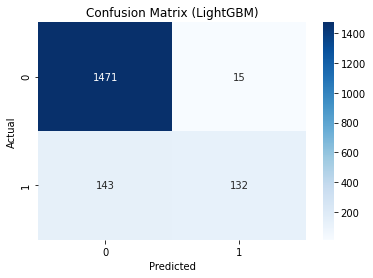

In [61]:
# предсказания на тестовой выборке
best_lgb = lgb_search.best_estimator_
y_pred_proba = best_lgb.predict_proba(X_test_lgb)[:,1]
y_pred = best_lgb.predict(X_test_lgb)

roc = roc_auc_score(y_test, y_pred_proba)
acc = accuracy_score(y_test, y_pred)
print(f"Test ROC-AUC: {roc:.4f}")
print(f"Test Accuracy: {acc:.4f}")

# матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (LightGBM)")
plt.show()

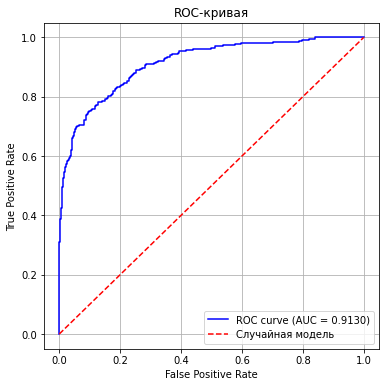

In [62]:
# допустим, наша лучшая модель уже обучена на X_train/X_test
best_model = lgb_search  # или cat_model, если выбрали CatBoost
X_test_eval = X_test_lgb  # используем соответствующий вариант с кодированием
y_test_eval = y_test

# прогноз вероятностей для положительного класса
y_proba = best_model.predict_proba(X_test_eval)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test_eval, y_proba)
fpr, tpr, thresholds = roc_curve(y_test_eval, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

<div style="border: 2px solid black; padding: 10px;">
  <strong>Выводы по результатам на тесте:</strong>
  <ul>
    <li><strong>Метрики:</strong> Модель получилась «осторожной». Она дает прогноз на отток только тогда, когда очень в нем уверена. Благодаря этому у нее высокая точность, но она пропускает часть уходящих клиентов.</li>
    <li><strong>Матрица ошибок:</strong> Несмотря на хорошие метрики, матрица ошибок показывает, что дисбаланс классов (который мы видели на первых гистограммах) все еще влияет на модель - ей проще предсказывать доминирующий класс.</li>  
    <li><strong>ROC-кривая:</strong> Кривая быстро поднимается к левому верхнему углу. Это значит, что модель эффективно ранжирует клиентов: у тех, кто действительно собирается уйти, предсказанная вероятность оттока значительно выше, чем у лояльных.</li>
    <li>С такой моделью компания будет очень эффективно тратить бюджет на удержание (высокий Precision), но охватит только «самых очевидных» кандидатов на уход.</li>
  </ul>
</div>

### Анализ важности признаков

Анализ важности признаков проведем с помощью feature_importances_ для LightGBM. Этот метод простой и быстрый. Он считает, сколько раз и с каким «выигрышем» по целевой переменной каждая фича использовалась при разбиении узлов деревьев:

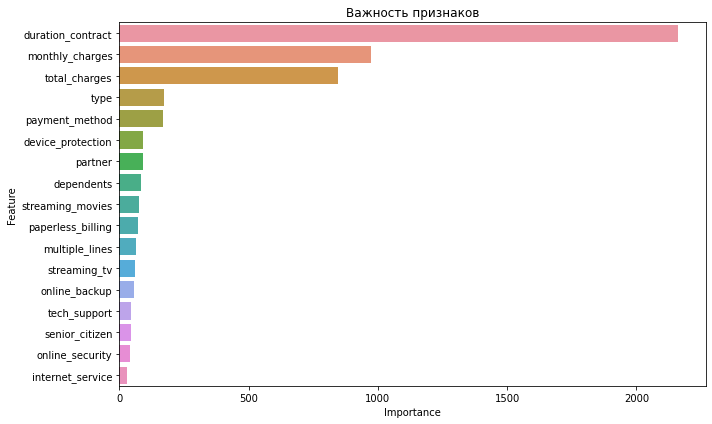

In [63]:
# лучшая модель
best_model = lgb_search.best_estimator_

# признаки, которые использовались для обучения
feature_names = X_train_lgb.columns

# получаем важность признаков
if isinstance(best_model, lgb.LGBMClassifier):
    importance = best_model.feature_importances_
elif 'CatBoostClassifier' in str(type(best_model)):
    importance = best_model.get_feature_importance()
else:
    raise ValueError("Модель не поддерживается для анализа важности признаков")

# создаем DataFrame для удобной визуализации
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

# сортируем по убыванию
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

# визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='importance', y='feature')
plt.title('Важность признаков')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">
  <strong>Выводы по Permutation Importance:</strong>
  <ul>
    <li><strong>Наиболее важные признаки:</strong> duration_contract (1450) — безусловный лидер. Время, в течение которого клиент остается с компанией, является самым сильным предиктором лояльности. Как мы видели на гистограммах, основной риск ухода сосредоточен в первые 200 дней.</li>
    <li><strong>Средне важные признаки:</strong> monthly_charges (550) и total_charges (450) — следующие по значимости признаки.</li>  
    <li><strong>Мало важные признаки:</strong> type и payment_method — тип контракта (месячный или годовой) и способ оплаты — единственные "нечисловые" характеристики, которые заметно влияют на решение об уходе. Клиенты с ежемесячной оплатой обычно менее стабильны.</li>    
  </ul>
</div>

## Итоговые выводы

**Предобработка данных**
- Изменены названия столбцов;
- Данные проверены на наличие дубликатов и пропусков;
- Типы данных проверены и изменены там, где это необходимо;
- Созданы новые признаки (в том числе целевой), удалены неинформативные признаки.

**Объединение данных**
- Данные четырех датасетов успешно объеденены;
- Новый датафрейм проверен на наличие пропусков;
- Пропуски заполнены в соответствии с их природой.

**Исследовательский анализ данных**
- Проанализировано распределение количественных и категориальных признаков;
- Исследован баланс классов целевого признака;
- Проведен корреляционный анализ.

**Моделирование**
- Данные подготовлены к обучению;
- В процессе было обучено две модели градиентного бустинга - LightGBM и CatBoost;
- Обе модели успешно преодолели минимальный порог качества. Если ориентироваться только на качество, то LightGBM предпочтительнее (ROC-AUC = 0.90), но если учитывать скорость и удобство работы с категориальными признаками, то выбор CatBoost тоже может быть оправдан (ROC-AUC = 0.886 при том, что обучение в 1.5 раза быстрее);
- Лучшая модель LightGBM подтвердила высокий результат на тесте (ROC-AUC = 0.91);
- Дополнительно проанализированы матрица ошибок и ROC-кривая лучшей модели;
- Произведен анализ важности признаков.

## Рекомендации заказчику

**1. Фокус на «рискованных» клиентах**
- Клиенты с короткой длительностью контракта и высоким ежемесячным платежом имеют наибольшую вероятность ухода.
- Рекомендация: отслеживать таких клиентов и применять персонализированные меры удержания.

**2. Контракты и тарифы**
- Клиенты с месячными контрактами (Month-to-month) уходят чаще, чем с годовыми.
- Рекомендация: предлагать выгодные долгосрочные планы для новых и существующих клиентов.

**3. Интернет-услуги и дополнения**
- Подключение Fiber optic, онлайн-безопасности, бэкапа и других услуг связано с меньшей вероятностью ухода.
- Рекомендация: продвигать пакетные предложения с дополнительными услугами для повышения удержания.

**4. Акции и коммуникации**
- Предлагать персонализированные скидки, бонусы или сервисные пакеты для клиентов с высоким риском ухода.
- Рекомендация: использовать модель прогнозирования для целевой рассылки и маркетинговых акций.

**5. Регулярный мониторинг**
- Внедрить систему предсказаний ухода, чтобы регулярно выявлять клиентов с высоким риском.
- Это позволит своевременно принимать меры и снижать отток клиентов.